## Importing libraries and formatting plots

In [1]:
# Importing crap
# %load_ext autoreload
# %autoreload 2

import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import numexpr

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import os

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.title_fontsize'] = 16
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['mathtext.fontset'] = 'cm'

## Reading in analysis output file

In [12]:
multipliers = [1e-1, 3e-1, 1e0, 3e0, 1e1]
radii = 0.005 * np.array(multipliers)

df_list = []
thresholds_list = []
radius_list = []

one_e_4_list = []
three_e_4_list = []
one_e_3_list = []
three_e_3_list = []
one_e_2_list = []

for multiplier in multipliers:
    df = pd.read_csv(f'./Data Files/analysis_output_{multiplier:.0e}.csv')
    df_list.append(df)

    thresholds = np.array(df.columns[5:], dtype=float)
    thresholds_list.append(thresholds)

    radius = np.array(df['source_radius'].to_list())
    radius_list.append(radius)

    one_e_4 = np.array(df['1.1e-04'].to_list())
    one_e_4_list.append(one_e_4)

    three_e_4 = np.array(df['3.4e-04'].to_list())
    three_e_4_list.append(three_e_4)

    one_e_3 = np.array(df['1.0e-03'].to_list())
    one_e_3_list.append(one_e_3)

    three_e_3 = np.array(df['3.1e-03'].to_list())
    three_e_3_list.append(three_e_3)

    one_e_2 = np.array(df['1.1e-02'].to_list())
    one_e_2_list.append(one_e_2)

In [5]:
ss_str_1 = np.array(df_list[0]['s1'].to_list(), dtype=str)
ss_str_2 = np.array(df_list[0]['s2'].to_list(), dtype=str)
alphas = np.array(df_list[0]['alpha'].to_list(), dtype=float)
ss_1 = np.array([numexpr.evaluate(str(s)) for s in df_list[0]['s1'].to_list()])
ss_2 = np.array([numexpr.evaluate(str(s)) for s in df_list[0]['s2'].to_list()])
q_1 = 1e-3
q_2 = 3e-4

ss_str_unique_1 = np.array(['0.2', '0.6', '1.0', '1/0.6', '1/0.2'], dtype=str)
ss_str_unique_2 = np.array(['0.2', '0.6', '1.0', '1/0.6', '1/0.2'], dtype=str)
ss_unique_1 = np.array([numexpr.evaluate(s) for s in ss_str_unique_1], dtype=float)
ss_unique_2 = np.array([numexpr.evaluate(s) for s in ss_str_unique_2], dtype=float)
alpha_unique = np.array([0, 45, 90, 135, 180])

print(ss_str_unique_1)
print(ss_str_unique_2)
print(alpha_unique)

['0.2' '0.6' '1.0' '1/0.6' '1/0.2']
['0.2' '0.6' '1.0' '1/0.6' '1/0.2']
[  0  45  90 135 180]


## Plotting fractional area above threshold as a function of threshold

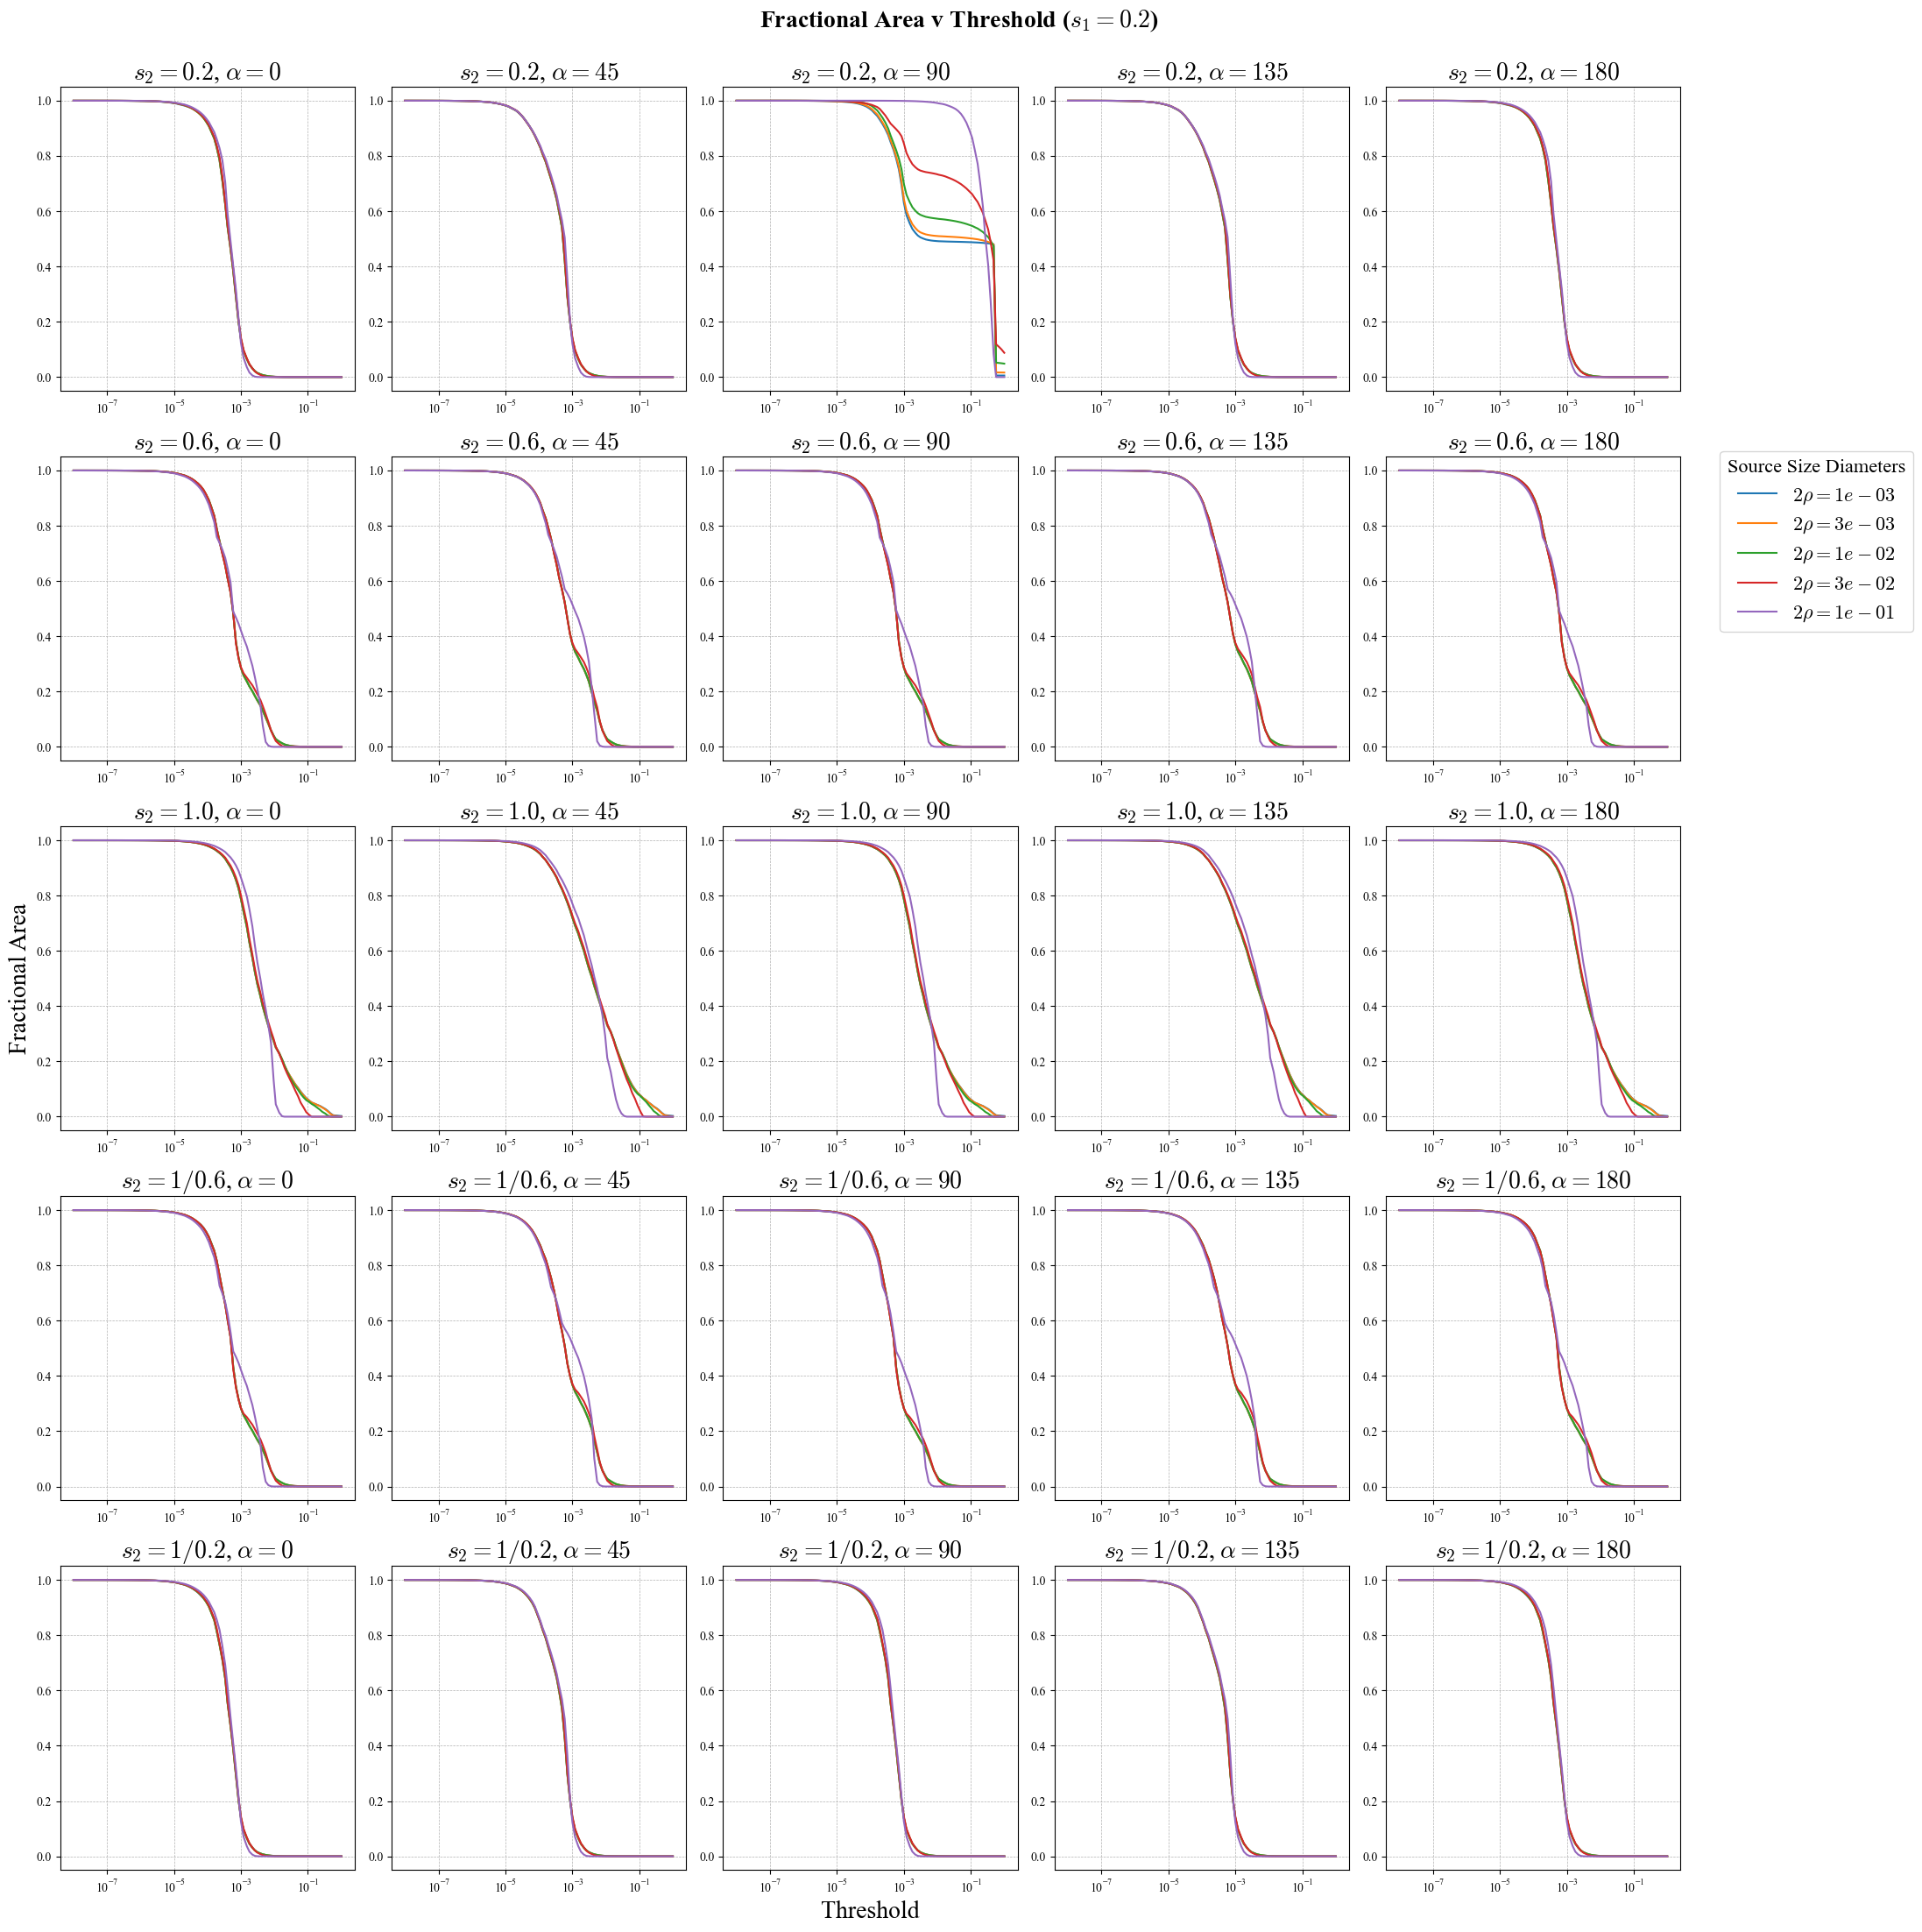

In [29]:
fig = plt.figure(figsize=(22, 22))
fig.set_tight_layout(True)
axes = fig.subplots(5, 5)

# combined_df = pd.concat(df_list, ignore_index=True)

s1 = '0.2'

fig.suptitle(f'Fractional Area v Threshold ($s_1 = {s1}$)', y=1.0)

for i, s2 in enumerate(ss_str_unique_2):
    for j, alpha in enumerate(alpha_unique):
        ax = axes[i, j]

        ax.set_title(f'$s_2={s2}$, $\\alpha={alpha}$')

        df_subset1 = df_list[0][(df_list[0]['s1'] == s1) & (df_list[0]['s2'] == s2) & (df_list[0]['alpha'] == alpha)]
        df_subset2 = df_list[1][(df_list[1]['s1'] == s1) & (df_list[1]['s2'] == s2) & (df_list[1]['alpha'] == alpha)]
        df_subset3 = df_list[2][(df_list[2]['s1'] == s1) & (df_list[2]['s2'] == s2) & (df_list[2]['alpha'] == alpha)]
        df_subset4 = df_list[3][(df_list[3]['s1'] == s1) & (df_list[3]['s2'] == s2) & (df_list[3]['alpha'] == alpha)]
        df_subset5 = df_list[4][(df_list[4]['s1'] == s1) & (df_list[4]['s2'] == s2) & (df_list[4]['alpha'] == alpha)]
        # df_subset = df_subset.sort_values(by='source_radius')

        ax.plot(thresholds, df_subset1.iloc[0, 5:], label=f'$2\\rho = {2*radii[0]:.0e}$')
        ax.plot(thresholds, df_subset2.iloc[0, 5:], label=f'$2\\rho = {2*radii[1]:.0e}$')
        ax.plot(thresholds, df_subset3.iloc[0, 5:], label=f'$2\\rho = {2*radii[2]:.0e}$')
        ax.plot(thresholds, df_subset4.iloc[0, 5:], label=f'$2\\rho = {2*radii[3]:.0e}$')
        ax.plot(thresholds, df_subset5.iloc[0, 5:], label=f'$2\\rho = {2*radii[4]:.0e}$')

        ax.set_xscale('log')
        # ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 2].set_xlabel('Threshold')
axes[2, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Source Size Diameters')

# fig.savefig('./Figures/fractional_area_v_threshold_s_less_than_1.png', dpi=300)

plt.show()

## First, plotting fractional area as a function of source star radius for different thresholds

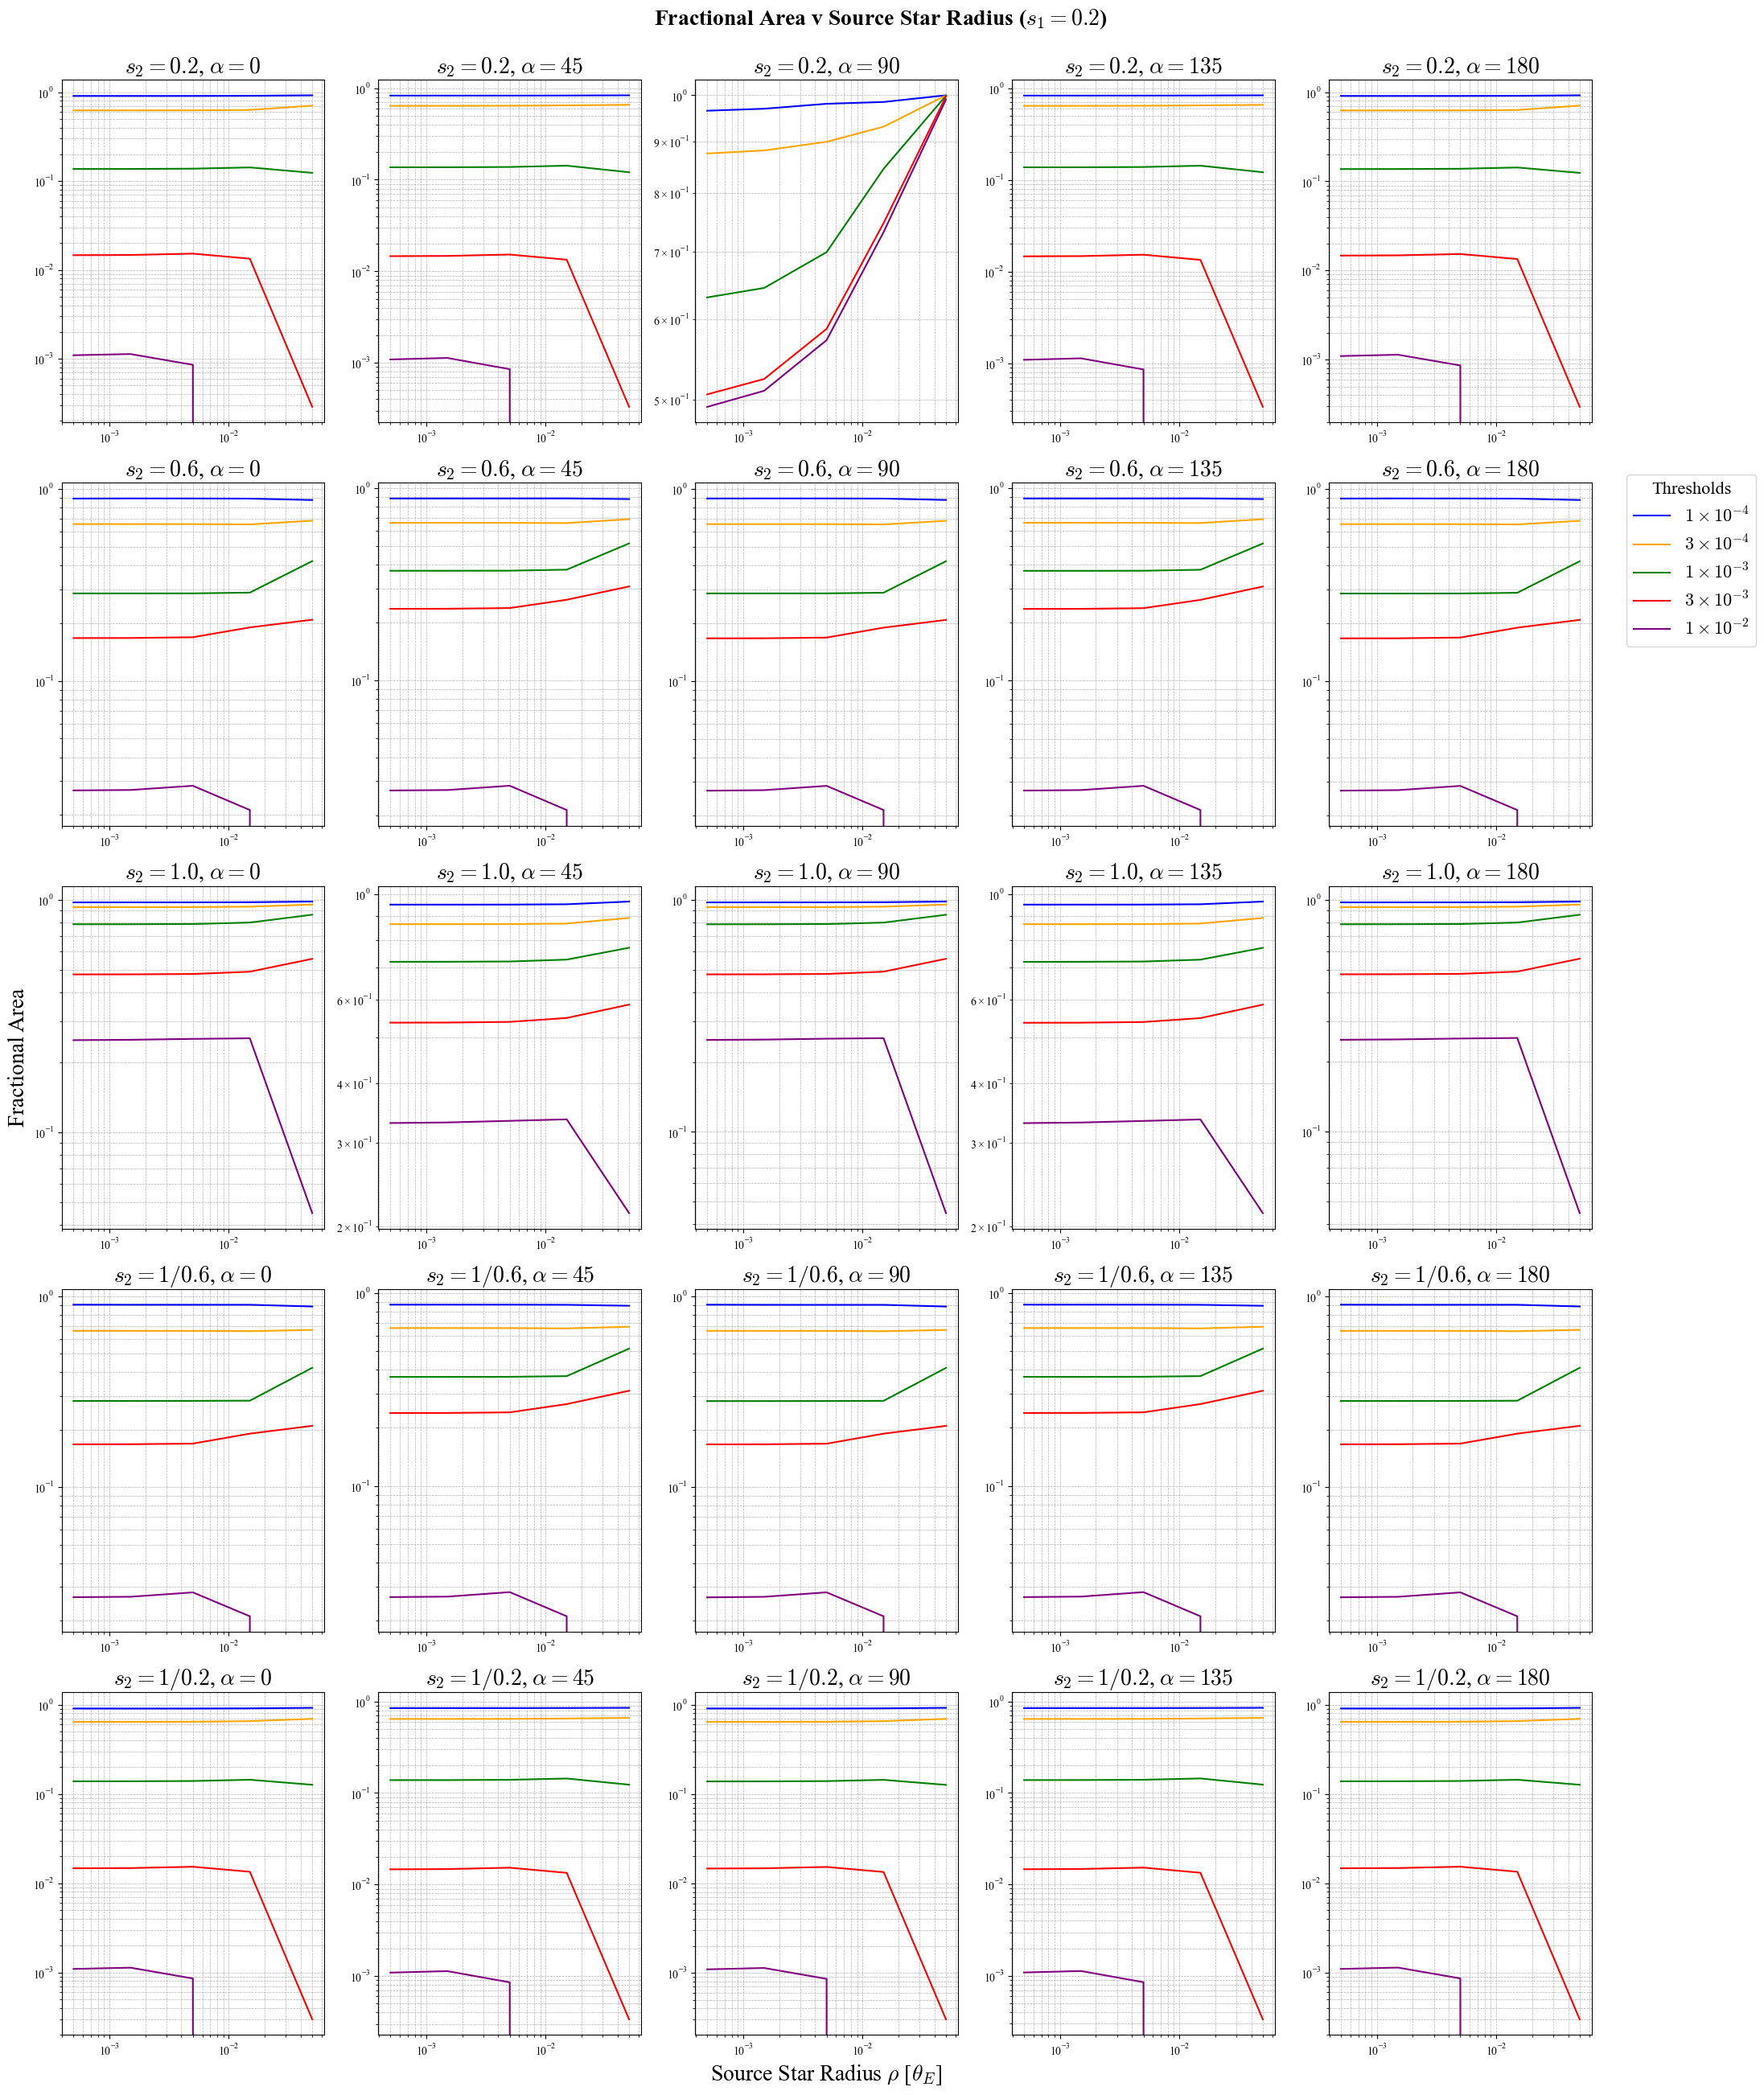

In [28]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(5, 5)

combined_df = pd.concat(df_list, ignore_index=True)

s1 = '0.2'

fig.suptitle(f'Fractional Area v Source Star Radius ($s_1 = {s1}$)', y=1.0)

for i, s2 in enumerate(ss_str_unique_2):
    for j, alpha in enumerate(alpha_unique):
        ax = axes[i, j]

        ax.set_title(f'$s_2={s2}$, $\\alpha={alpha}$')

        df_subset = combined_df[(combined_df['s1'] == s1) & (combined_df['s2'] == s2) & (combined_df['alpha'] == alpha)]
        df_subset = df_subset.sort_values(by='source_radius')

        ax.plot(df_subset['source_radius'], df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(df_subset['source_radius'], df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(df_subset['source_radius'], df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(df_subset['source_radius'], df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(df_subset['source_radius'], df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 2].set_xlabel('Source Star Radius $\\rho$ [$\\theta_E$]')
axes[2, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

# Second, plotting fractional area as a function of separation for different thresholds

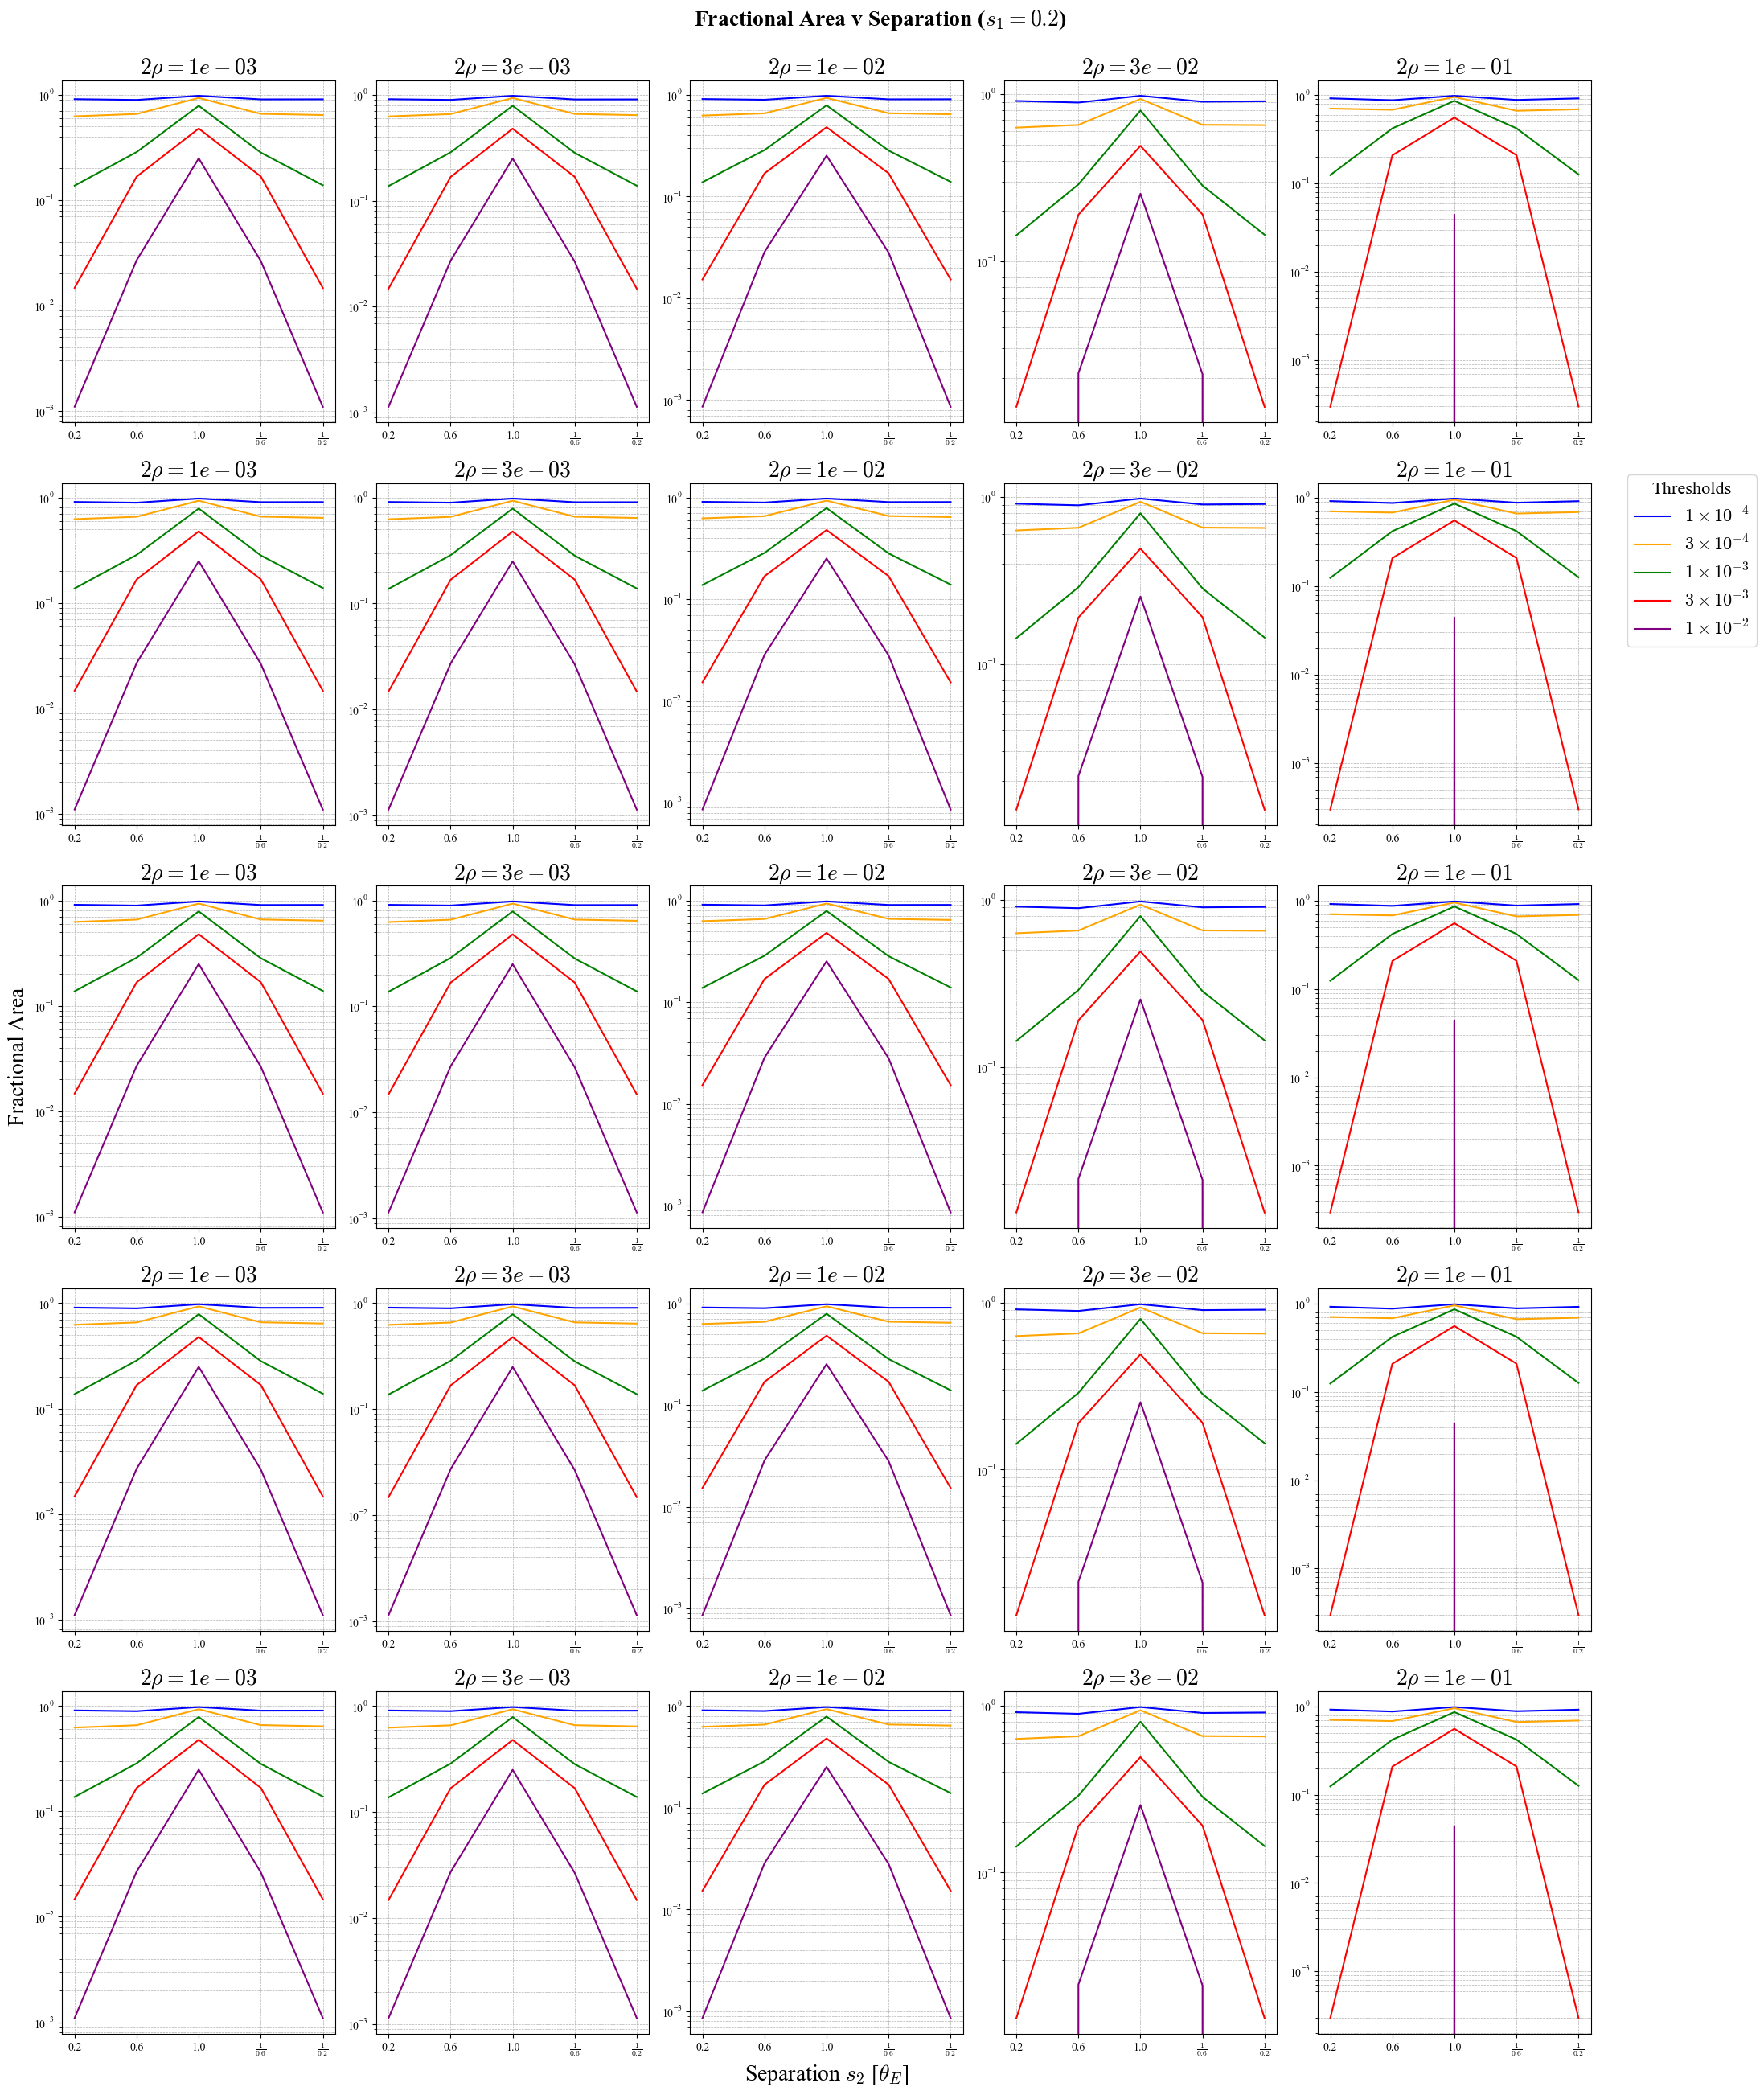

In [27]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(5, 5)

combined_df = pd.concat(df_list, ignore_index=True)

s1 = '0.2'

fig.suptitle(f'Fractional Area v Separation ($s_1 = {s1}$)', y=1.0)

for i, s2 in enumerate(ss_str_unique_2):
    for j, radius in enumerate(radii):
        ax = axes[i, j]

        ax.set_title(f'$2\\rho = {2*radius:.0e}$')

        df_subset = df_list[j][(df_list[j]['s1'] == s1) & (df_list[j]['alpha'] == alpha)]
        # df_subset = df_subset.sort_values(by='s')

        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')
        # ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.set_xticks(np.linspace(0, 1, len(df_subset)))

        # Using stacked fractions for the x-ticks to show separation values instead of indices
        ax.set_xticklabels([f'$\\frac{{{s.split("/")[0]}}}{{{s.split("/")[1]}}}$' if numexpr.evaluate(s) > 1.0 else f'{s}' for s in ss_str_unique_2])

axes[-1, 2].set_xlabel('Separation $s_2$ [$\\theta_E$]')
axes[2, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

# fig.savefig('./Figures/fractional_area_v_separation.png', dpi=300)

plt.show()

## Fourth, plotting q and s with fractional area as color scale for different thresholds

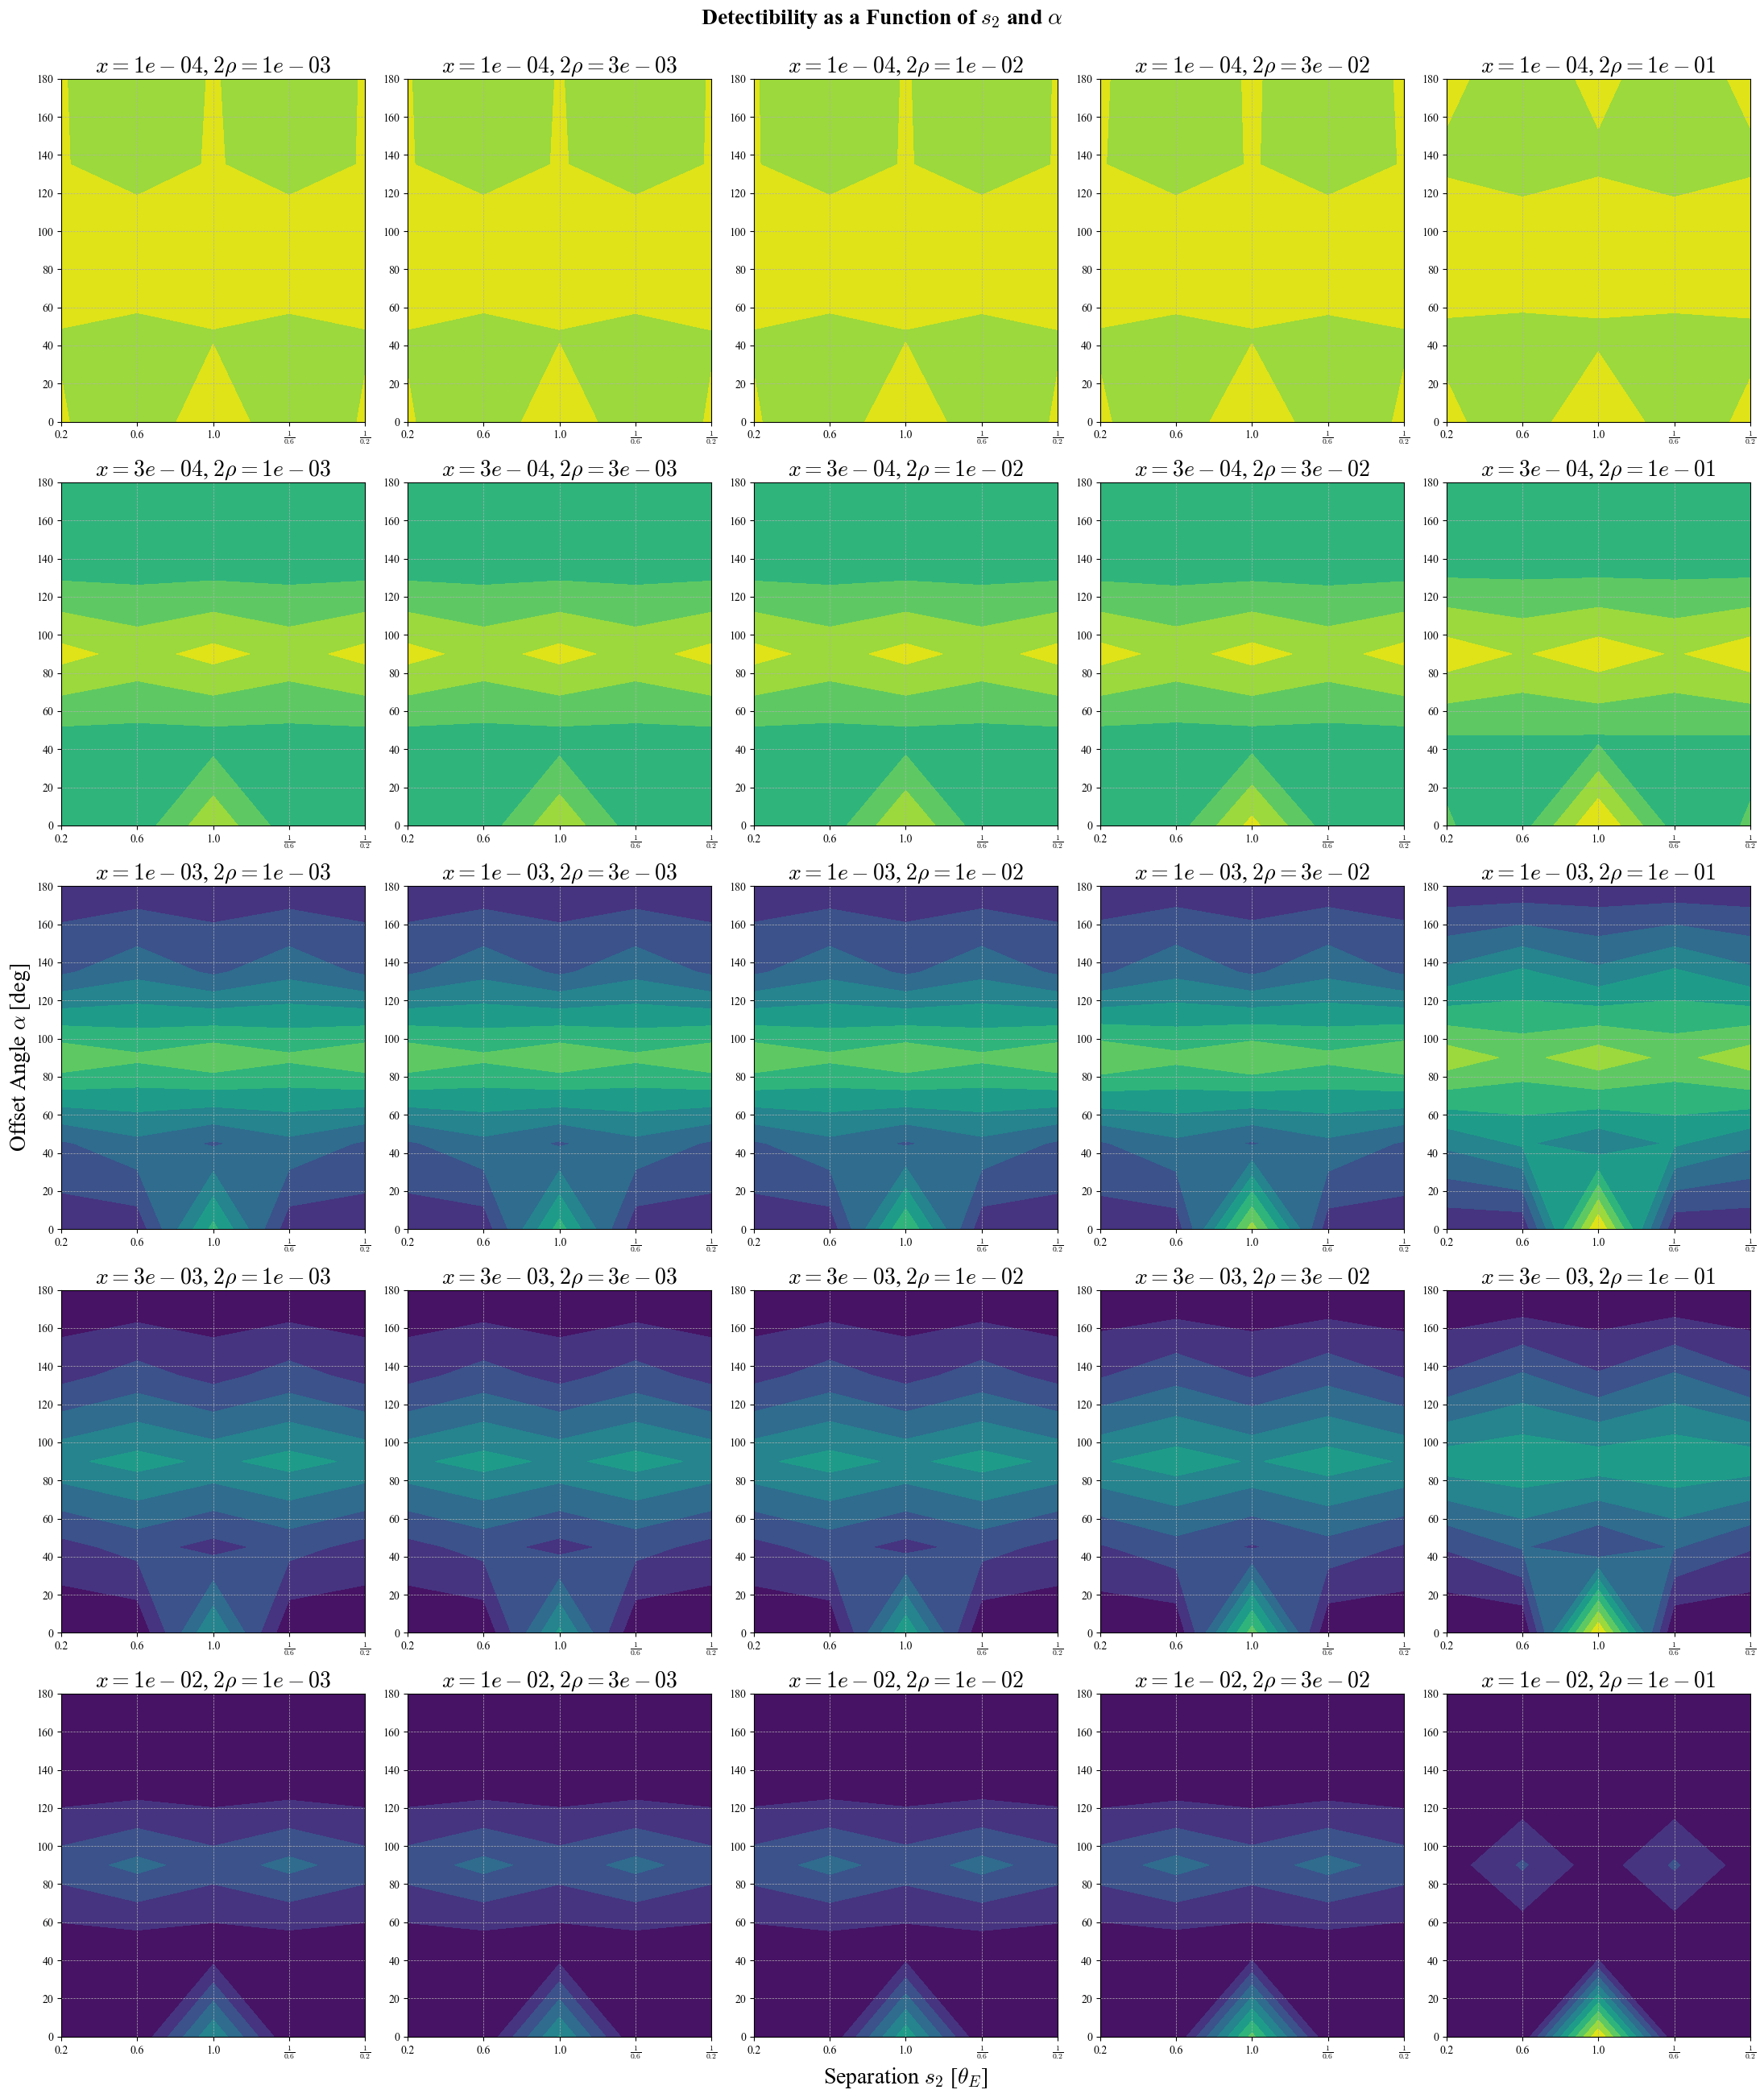

In [26]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(5, 5)

fig.suptitle('Detectibility as a Function of $s_2$ and $\\alpha$', y=1.0)

for i, threshold in enumerate([1.1e-04, 3.4e-04, 1.0e-03, 3.1e-03, 1.1e-02]):
    for j, radius in enumerate(radii):
        ax = axes[i, j]

        ax.set_title(f'$x={threshold:.0e}$, $2\\rho = {2*radius:.0e}$')

        df_subset = df_list[j][(df_list[j]['s1'] == s1)]
        # df_subset = df_subset.sort_values(by='q').reset_index(drop=True)

        # Fixing holes in data
        # empty_arr = ['1/0.2', 3e-4] + [np.nan] * 102
        # df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[116.5])], ignore_index=False)

        # empty_arr = ['1/0.2', 1e-3] + [np.nan] * 102
        # df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[117.5])], ignore_index=False)
        # df_subset = df_subset.sort_index().reset_index(drop=True)

        # empty_arr = ['1/0.4', 1e-3] + [np.nan] * 102
        # df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[103.5])], ignore_index=False)

        # df_subset = df_subset.sort_index().reset_index(drop=True)

        # ax.imshow(np.array(df_subset[f'{threshold:.1e}']).reshape((17, 7)).T, extent=[
        #     ss_unique_1.min(), ss_unique_1.max(),
        #     qs_unique_1.min(), qs_unique_1.max()
        # ], aspect='auto', origin='lower', norm=plt.Normalize(vmin=0, vmax=1), cmap='viridis')

        ax.contourf(
            np.linspace(0, 1, 5),
            alpha_unique,
            np.array(df_subset[f'{threshold:.1e}']).reshape((5, 5)),
            levels=np.linspace(0, 1, 11),
            cmap='viridis',
            # vmin=0, vmax=1
        )

        # ax.set_xscale('log')
        # ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.set_xticks(np.linspace(0, 1, 5))
        # ax.set_xticklabels(ss_str_unique_1)
        ax.set_xticklabels([f'$\\frac{{{s.split("/")[0]}}}{{{s.split("/")[1]}}}$' if numexpr.evaluate(s) > 1.0 else f'{s}' for s in ss_str_unique_2])

axes[-1, 2].set_xlabel('Separation $s_2$ [$\\theta_E$]')
axes[2, 0].set_ylabel('Offset Angle $\\alpha$ [deg]')

# axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

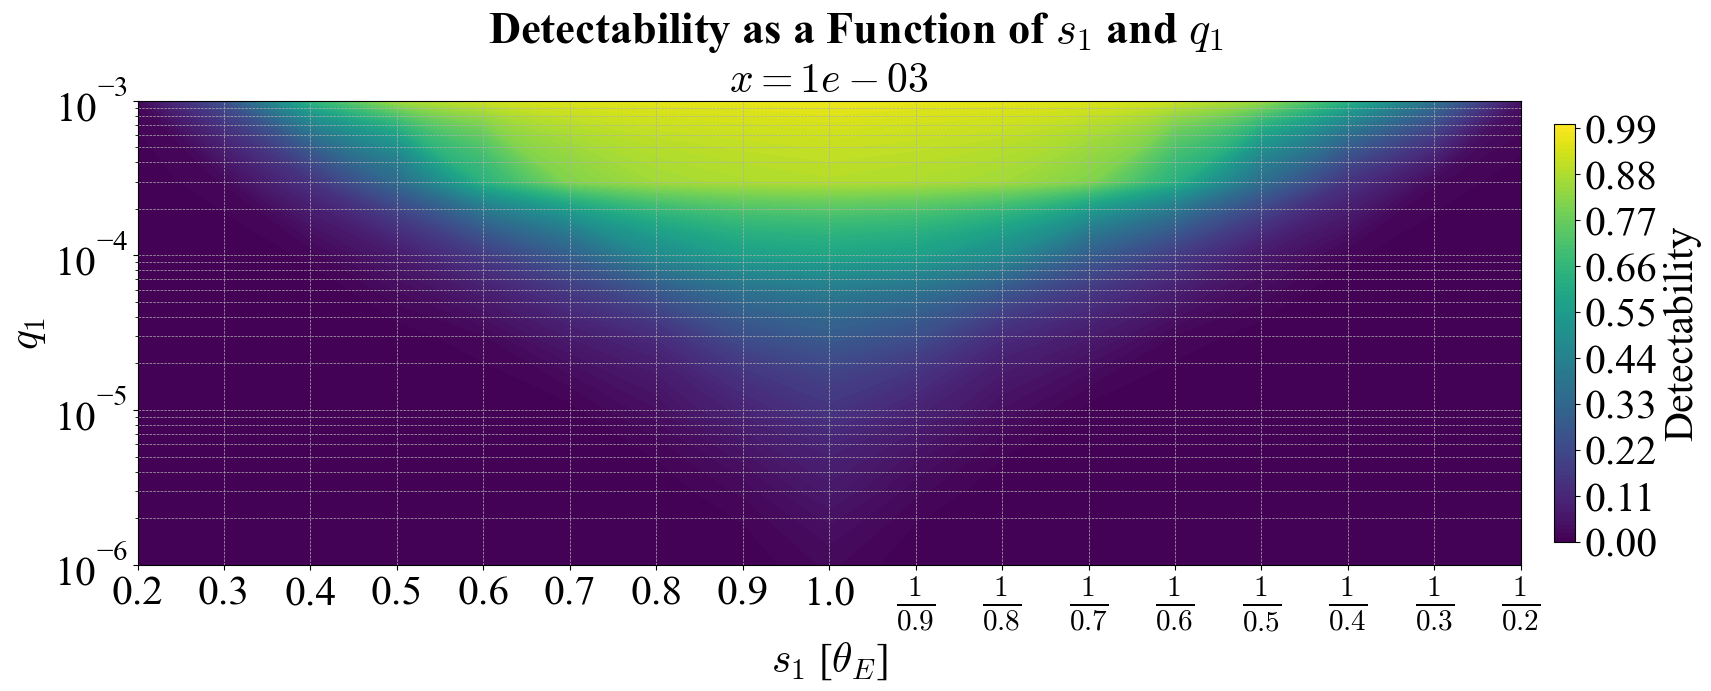

In [44]:
# Setting up plotting style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 32
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (14, 9)
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 30
plt.rcParams['figure.labelsize'] = 30
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 28
plt.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(17, 6.8))
fig.set_constrained_layout(True)
ax = fig.add_subplot()

fig.suptitle('Detectability as a Function of $s_1$ and $q_1$')

threshold = 1.0e-03
multiplier = 1.00e0

ax.set_title(f'$x={threshold:.0e}$')

df_subset = df_list[2]

img = ax.contourf(
    np.linspace(0, 1, 17),
    qs_unique_1,
    np.array(df_subset[f'{threshold:.1e}']).reshape((7, 17)),
    levels=np.linspace(0, 1, 101),
    cmap='viridis',
    # vmin=0, vmax=1
)

bar = fig.colorbar(img, ax=ax, shrink=0.9, pad=0.01, label='Detectability')

# ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_xticks(np.linspace(0, 1, 17))
# ax.set_xticklabels(ss_str_unique_1)
ax.set_xticklabels([f'$\\frac{{{s.split("/")[0]}}}{{{s.split("/")[1]}}}$' if numexpr.evaluate(s) > 1.0 else f'{s}' for s in ss_str_unique_1])

ax.set_xlabel('$s_1$ [$\\theta_E$]')
ax.set_ylabel('$q_1$')

# axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')
fig.savefig('./Figures/Detectability_q_s.png', dpi=300, bbox_inches='tight')

plt.show()